# 02 · Customer Behavior

**Business question:** Who are H&M's most valuable customers, how well does the
business keep new customers, and which products bring people back?

A **shopping day** (or basket) is all of a customer's purchases on one date.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hm_analytics import HM, charts

charts.apply_style()
pd.options.display.float_format = "{:,.3f}".format
hm = HM()

## 1. How often do customers shop?

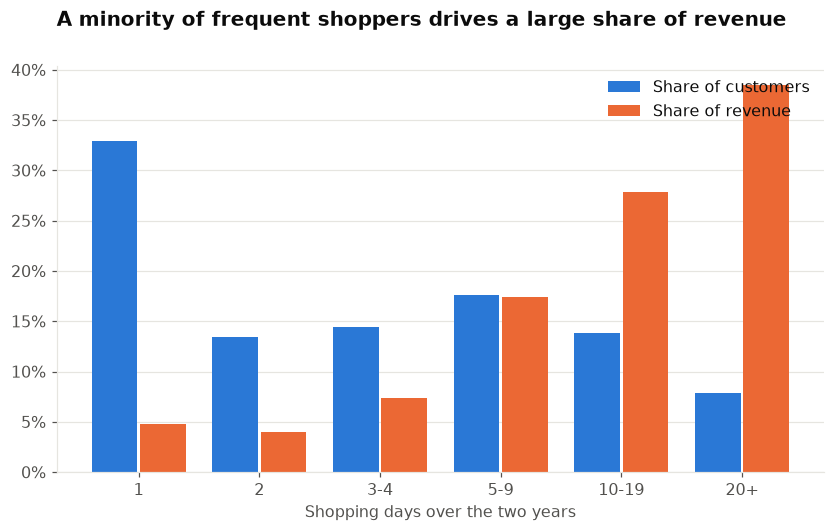

,shopping_days,sort_key,customers,customer_share,revenue_share,avg_spend
0,1,1,447973,0.329,0.048,0.094
1,2,2,183116,0.134,0.040,0.193
2,3-4,3,197124,0.145,0.074,0.332
3,5-9,5,239266,0.176,0.174,0.645
4,10-19,10,188085,0.138,0.279,1.312
5,20+,20,106717,0.078,0.385,3.191


In [2]:
freq = hm.q("visit_frequency_distribution")

fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(freq))
ax.bar(x - 0.2, freq.customer_share, width=0.38, label="Share of customers", color=charts.SERIES[0])
ax.bar(x + 0.2, freq.revenue_share, width=0.38, label="Share of revenue", color=charts.SERIES[1])
ax.set_xticks(x, freq.shopping_days)
ax.set_xlabel("Shopping days over the two years")
charts.pct_axis(ax, "y")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper right")
ax.set_title("A minority of frequent shoppers drives a large share of revenue")
charts.save(fig, "02_frequency_distribution")
plt.show()
freq

## 2. RFM segmentation

Each customer is scored 1–5 on **Recency** (days since last purchase), **Frequency**
(shopping days) and **Monetary** value (total spend), then grouped into segments
(definitions in `sql/00_build_tables.sql`).

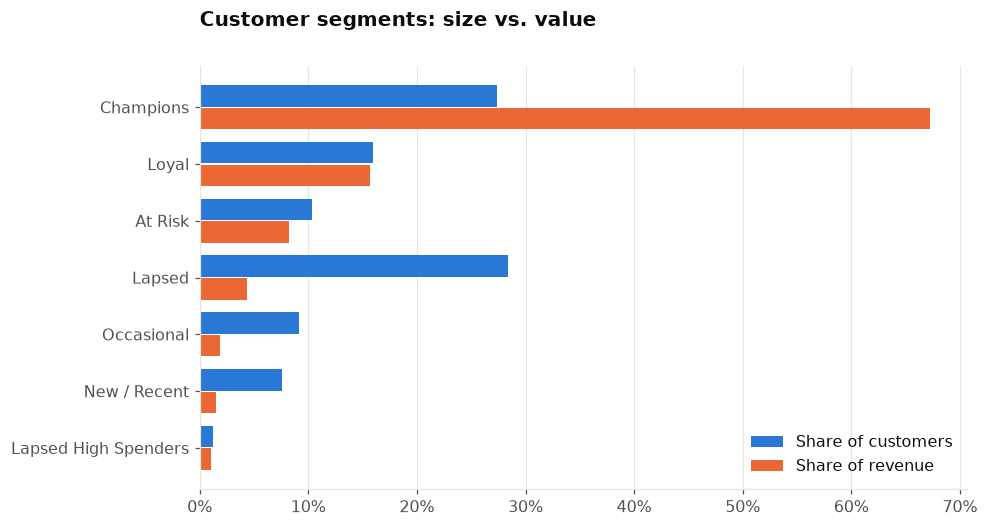

,segment,customers,customer_share,revenue_share,avg_recency_days,avg_shopping_days,avg_spend
0,Champions,372762,0.274,0.673,36.167,16.431,1.597
1,Loyal,217167,0.159,0.157,116.826,6.333,0.640
2,At Risk,141263,0.104,0.082,380.483,5.420,0.517
3,Lapsed,387044,0.284,0.043,504.314,1.227,0.099
4,Occasional,124718,0.092,0.019,158.318,1.343,0.133
5,New / Recent,102721,0.075,0.015,47.229,1.411,0.130
6,Lapsed High Spenders,16606,0.012,0.011,478.711,1.619,0.566


In [3]:
segments = hm.q("rfm_segment_summary")
order = segments.sort_values("revenue_share", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(order))[::-1]
ax.barh(y + 0.2, order.customer_share, height=0.38, label="Share of customers", color=charts.SERIES[0])
ax.barh(y - 0.2, order.revenue_share, height=0.38, label="Share of revenue", color=charts.SERIES[1])
ax.set_yticks(y, order.segment)
charts.pct_axis(ax, "x")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
ax.set_title("Customer segments: size vs. value")
charts.save(fig, "02_rfm_segments")
plt.show()
segments

In [4]:
hm.q("rfm_segment_profile")

,segment,avg_age,avg_online_share,active_club_member_share,fashion_news_share,avg_units_per_basket
0,At Risk,37.613,0.589,0.939,0.361,3.466
1,Champions,35.468,0.601,0.992,0.455,3.509
2,Lapsed,38.193,0.655,0.848,0.276,3.102
3,Lapsed High Spenders,37.900,0.876,0.806,0.239,11.905
4,Loyal,35.732,0.681,0.963,0.367,3.602
5,New / Recent,34.084,0.714,0.937,0.326,3.440
6,Occasional,35.166,0.852,0.914,0.243,3.554


## 3. Retention by first-purchase cohort

Customers are grouped by the month of their first purchase in the data. The first
three cohorts are dropped: many of those "new" customers had simply shopped before
the data begins.

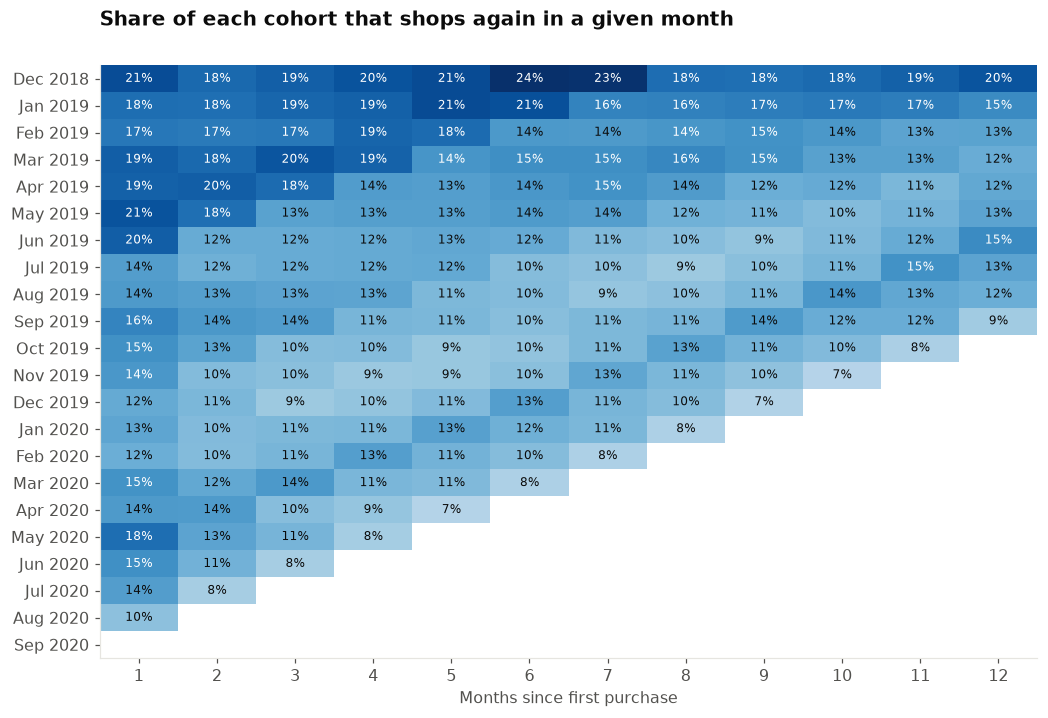

In [5]:
cohorts = hm.q("cohort_retention")
first_cohorts = sorted(cohorts.cohort_month.unique())[:3]
cohorts = cohorts[~cohorts.cohort_month.isin(first_cohorts)]
grid = cohorts.pivot_table(index="cohort_month", columns="months_since_first", values="retention_rate")
grid = grid.loc[:, 1:12]
grid.index = pd.to_datetime(grid.index).strftime("%b %Y")

fig, ax = plt.subplots(figsize=(11, 7))
ax.imshow(grid.values, cmap="Blues", aspect="auto", vmin=0)
ax.set_xticks(range(grid.shape[1]), grid.columns)
ax.set_yticks(range(grid.shape[0]), grid.index)
ax.set_xlabel("Months since first purchase")
ax.grid(False)
vmax = np.nanmax(grid.values)
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        value = grid.values[i, j]
        if not np.isnan(value):
            ax.text(j, i, f"{value:.0%}", ha="center", va="center", fontsize=8,
                    color="white" if value > vmax * 0.6 else charts.TEXT)
ax.set_title("Share of each cohort that shops again in a given month")
charts.save(fig, "02_cohort_retention")
plt.show()

## 4. Which first purchases lead to repeat customers?

For customers whose first purchase falls at least 90 days after the data starts, what
share come back within 90 days, split by what was in their first basket? This is
descriptive: a high rate could reflect the kind of shopper who buys that category,
not the category itself. "Special Offers" and "Unknown" are left out because they are
not product categories.

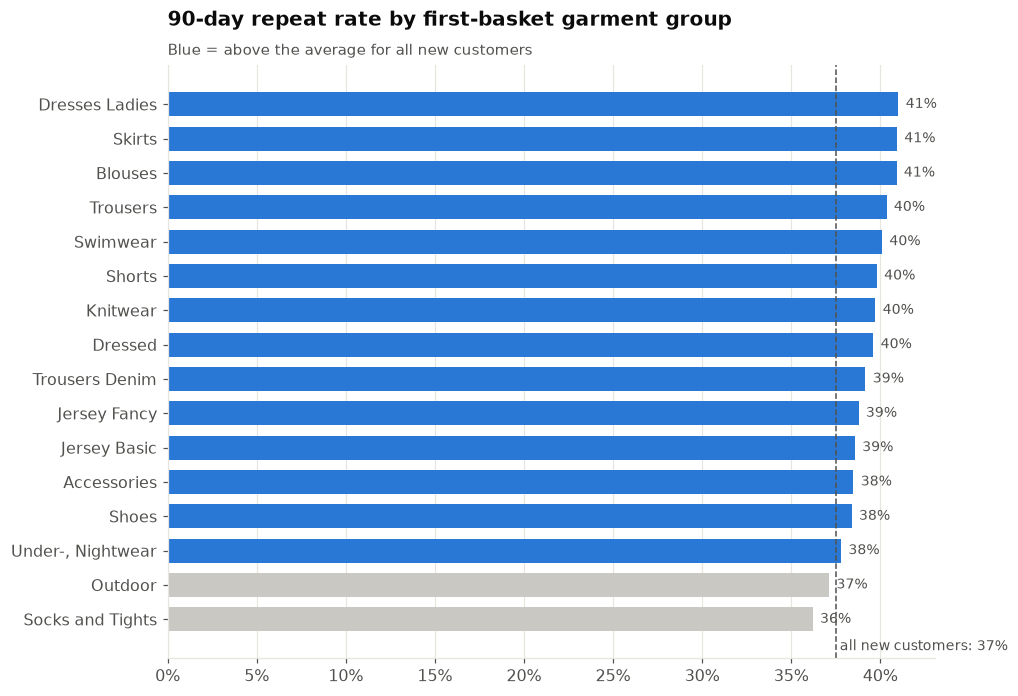

744,599 new customers, 37.5% returned within 90 days


,garment_group_name,new_customers,repeat_rate_90d
0,Dresses Ladies,100186,0.410
1,Skirts,33798,0.409
2,Blouses,118211,0.409
3,Trousers,149989,0.403
4,Swimwear,90893,0.401
5,Shorts,38291,0.398
6,Knitwear,107252,0.397
7,Dressed,25087,0.396
8,Trousers Denim,65849,0.392
9,Jersey Fancy,229219,0.388


In [6]:
baseline = hm.q("new_customer_repeat_rate").iloc[0]
entry = hm.q("repeat_rate_by_entry_category")
entry = entry[entry.new_customers >= entry.new_customers.sum() * 0.01]   # ignore tiny groups

fig, ax = plt.subplots(figsize=(9, 7))
charts.barh(ax, entry.garment_group_name, entry.repeat_rate_90d,
            highlight=set(entry.loc[entry.repeat_rate_90d > baseline.repeat_rate_90d, "garment_group_name"]))
ax.axvline(baseline.repeat_rate_90d, color=charts.TEXT_SECONDARY, linewidth=1, linestyle="--")
ax.text(baseline.repeat_rate_90d, -0.9, f" all new customers: {baseline.repeat_rate_90d:.0%}",
        color=charts.TEXT_SECONDARY, fontsize=9)
charts.pct_axis(ax, "x")
ax.set_title("90-day repeat rate by first-basket garment group")
charts.subtitle(ax, "Blue = above the average for all new customers")
charts.save(fig, "02_repeat_rate_by_entry_category")
plt.show()
print(f"{int(baseline.new_customers):,} new customers, {baseline.repeat_rate_90d:.1%} returned within 90 days")
entry

## 5. Age and category preferences

In [7]:
hm.q("age_band_summary")

,age_band,customers,customer_share,revenue_share,avg_spend,avg_shopping_days,avg_online_share
0,16-24,353827,0.260,0.191,0.477,5.967,0.663
1,25-34,391009,0.287,0.367,0.830,7.487,0.686
2,35-44,167950,0.123,0.127,0.671,6.249,0.667
3,45-54,252409,0.185,0.196,0.688,7.056,0.635
4,55+,181325,0.133,0.115,0.559,6.421,0.638
5,Unknown,15761,0.012,0.004,0.241,2.948,0.744


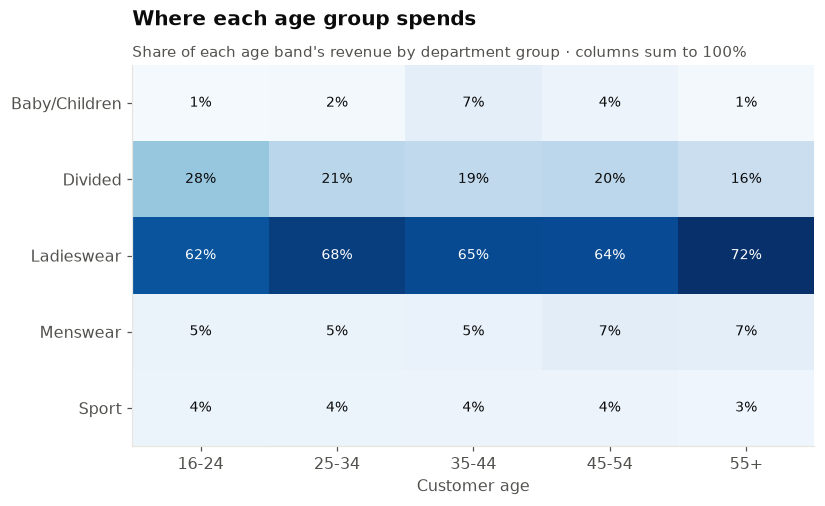

In [8]:
mix = hm.q("age_band_category_mix")
grid = mix.pivot_table(index="index_group_name", columns="age_band", values="share_of_band_revenue").fillna(0)
grid = grid[[c for c in grid.columns if c != "Unknown"]]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.imshow(grid.values, cmap="Blues", aspect="auto", vmin=0)
ax.set_xticks(range(grid.shape[1]), grid.columns)
ax.set_yticks(range(grid.shape[0]), grid.index)
ax.set_xlabel("Customer age")
ax.grid(False)
vmax = grid.values.max()
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        value = grid.values[i, j]
        ax.text(j, i, f"{value:.0%}", ha="center", va="center", fontsize=9,
                color="white" if value > vmax * 0.6 else charts.TEXT)
ax.set_title("Where each age group spends")
charts.subtitle(ax, "Share of each age band's revenue by department group · columns sum to 100%")
charts.save(fig, "02_age_category_mix")
plt.show()

## 6. Channel and loyalty-program behavior

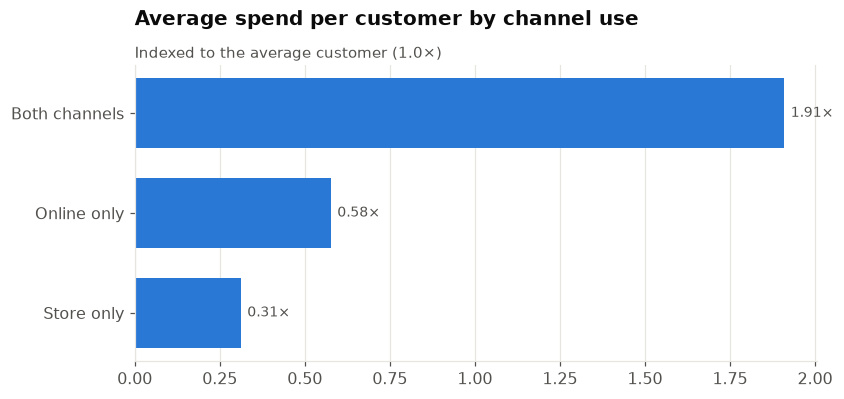

,shopper_type,customers,customer_share,revenue_share,avg_spend,avg_shopping_days
0,Both channels,483255,0.355,0.677,1.240,13.034
1,Online only,625163,0.459,0.265,0.374,3.143
2,Store only,253863,0.186,0.058,0.203,3.216


In [9]:
channel = hm.q("channel_preference")
fig, ax = plt.subplots(figsize=(8, 3.5))
spend_index = channel.avg_spend / (channel.avg_spend * channel.customer_share).sum()
charts.barh(ax, channel.shopper_type, spend_index, fmt="{:.2f}×")
ax.set_title("Average spend per customer by channel use")
charts.subtitle(ax, "Indexed to the average customer (1.0×)")
charts.save(fig, "02_channel_spend")
plt.show()
channel

In [10]:
hm.q("engagement_summary")

,attribute,value,customers,avg_spend,avg_shopping_days
0,Club member status,ACTIVE,1263183,0.683,7.029
1,Club member status,PRE-CREATE,92578,0.216,1.955
2,Club member status,UNKNOWN,6054,0.303,2.990
3,Club member status,LEFT CLUB,466,0.553,4.897
4,Fashion news frequency,None,887598,0.574,5.681
5,Fashion news frequency,Regularly,473843,0.791,8.513
6,Fashion news frequency,Monthly,840,0.307,4.088


## 7. What gets bought together?

**Lift** = how much more often two garment groups appear in the same basket than if
customers picked them independently. Lift of 2 means twice as often as chance.
Only product categories are paired ("Special Offers" and "Unknown" are left out).

In [11]:
hm.q("top_category_pairs")

,group_a,group_b,baskets_both,support,pct_of_a_baskets_with_b,pct_of_b_baskets_with_a,lift
0,Shorts,Swimwear,79080,0.009,0.184,0.093,1.974
1,Shorts,Skirts,41559,0.005,0.097,0.092,1.947
2,Shirts,Shorts,11934,0.001,0.089,0.028,1.887
3,Dresses Ladies,Skirts,113249,0.012,0.089,0.251,1.803
4,Shorts,Trousers Denim,67096,0.007,0.156,0.083,1.762
5,Dresses/Skirts girls,Jersey Fancy,20446,0.002,0.530,0.007,1.738
6,Dresses Ladies,Shorts,102132,0.011,0.081,0.238,1.704
7,Dressed,Trousers,103408,0.011,0.323,0.059,1.679
8,Jersey Basic,Shorts,136996,0.015,0.078,0.319,1.647
9,Jersey Fancy,Woven/Jersey/Knitted mix Baby,18834,0.002,0.007,0.500,1.638


## Findings

- **Value concentration:** a third of customers (33%) shopped on only one day and
  contribute under 5% of revenue, while the 8% who shopped on 20+ days contribute 39%.
  In RFM terms, Champions are 27% of customers and 67% of revenue; Lapsed customers
  are 28% of the base but 4% of revenue.
- **Retention:** 37.5% of new customers buy again within 90 days. In the cohort view,
  monthly return rates for cohorts from mid-2019 onward mostly sit around 10–15%,
  below the earliest cohorts shown (Dec 2018 – Mar 2019, mostly 15–20%), which likely
  still include some existing customers first seen near the start of the data.
- **Entry categories:** 90-day repeat rates by first-basket garment group sit in a
  narrow 36–41% band (Dresses Ladies, Skirts and Blouses highest at 41%; Shirts and
  Socks and Tights lowest at 36%). First category is a weak signal of short-term
  loyalty on its own.
- **Channel and age:** customers who shop both online and in store are 36% of customers
  but 68% of revenue; online-only shoppers are 46% of customers but 26% of revenue.
  The 25–34 age band is the most valuable (29% of customers, 37% of revenue). These are
  associations, not proof that a second channel raises spend.
- **Basket affinity:** the strongest cross-category pairs are seasonal: Shorts with
  Swimwear (lift 1.97) and Shorts with Skirts (1.95), plus Dresses with Skirts (1.80),
  which points to summer outfit-building as a cross-sell opportunity.